In [1]:
import pandas as pd 

In [2]:
claimants_df = pd.read_csv('claimants.csv')
claimants_df

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [3]:
claimants_df.shape

(1340, 7)

In [4]:
claimants_df.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [5]:
claimants_df.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

In [6]:
claimants_df.dropna(inplace=True)

In [7]:
claimants_df

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [8]:
X = claimants_df[['CLMSEX', 'CLMINSUR', 'SEATBELT', 'LOSS']]

In [9]:
y = claimants_df['ATTORNEY'] 

In [10]:
X

,CLMSEX,CLMINSUR,SEATBELT,LOSS
0,0.0,1.0,0.0,34.940
1,1.0,0.0,0.0,0.891
2,0.0,1.0,0.0,0.330
3,0.0,1.0,1.0,0.037
4,0.0,1.0,0.0,0.038
...,...,...,...,...
1334,1.0,1.0,0.0,0.060
1336,1.0,1.0,0.0,3.705
1337,1.0,1.0,0.0,0.099
1338,1.0,0.0,0.0,3.177


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split( X , y ,test_size=0.20, shuffle=True, random_state=34)

In [13]:
logistic_model = LogisticRegression()

In [14]:
logistic_model.fit(X_train,y_train)

LogisticRegression()

In [15]:
y_predicted_train = logistic_model.predict(X_train)

In [16]:
y_predicted_test = logistic_model.predict(X_test)
y_predicted_test

array([0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0])

### Model evaluation 

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve , roc_auc_score, precision_score

#### Train data

In [18]:
print(confusion_matrix(y_train, y_predicted_train))

[[292 161]
 [103 320]]


In [19]:
print(classification_report(y_train, y_predicted_train))

              precision    recall  f1-score   support

           0       0.74      0.64      0.69       453
           1       0.67      0.76      0.71       423

    accuracy                           0.70       876
   macro avg       0.70      0.70      0.70       876
weighted avg       0.70      0.70      0.70       876



### 
   1. ROC curve(receiver operative characteristics)
   2. AUC - Area under this curve 

0.7005463967560628


Text(0, 0.5, 'True Positive Rate')

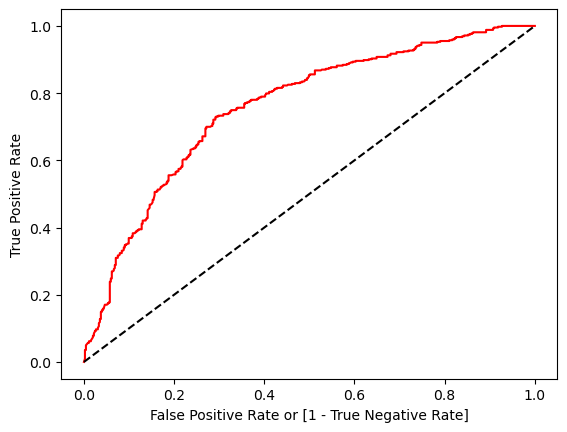

In [39]:
fpr, tpr, thresholds = roc_curve(y_train, logistic_model.predict_proba(X_train)[:,1])
auc = roc_auc_score(y_train, y_predicted_train)
print(auc)


import matplotlib.pylab as plt
plt.plot(fpr, tpr, color='red', label='logit model (area = %0.2f)'%auc) 
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

#### Test data

In [20]:
print(confusion_matrix(y_test, y_predicted_test))

[[81 44]
 [24 71]]


In [21]:
print(classification_report(y_test, y_predicted_test))

              precision    recall  f1-score   support

           0       0.77      0.65      0.70       125
           1       0.62      0.75      0.68        95

    accuracy                           0.69       220
   macro avg       0.69      0.70      0.69       220
weighted avg       0.70      0.69      0.69       220



0.6976842105263159


Text(0, 0.5, 'True Positive Rate')

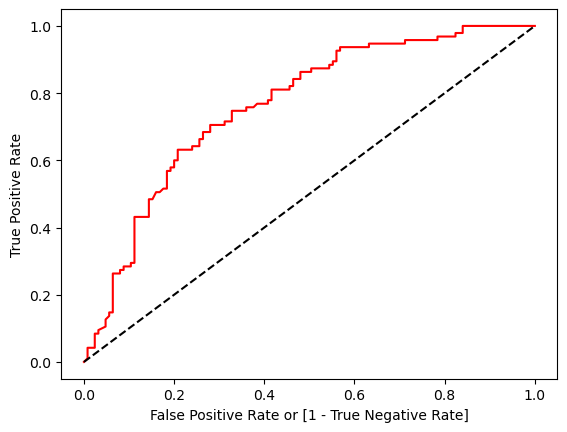

In [41]:
fpr, tpr, thresholds = roc_curve(y_test, logistic_model.predict_proba(X_test)[:,1])
auc = roc_auc_score(y_test , y_predicted_test)
print(auc)

import matplotlib.pylab as plt
plt.plot(fpr, tpr, color='red', label='logit model (area = %0.2f)'%auc) 
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

### Deploy 

In [22]:
from pickle import dump

In [23]:
dump(logistic_model, open("claimants.pkl",'wb'))